# Kwant — Theory and Practice · Chapter 2
## Shapes, spin and band structure

*Part I · Sections 5–7 · Figures 7–13* &nbsp;·&nbsp; [← Chapter 1](01_Foundations.ipynb) · [Contents](00_Contents.ipynb) · [Chapter 3 →](03_Graphene_and_Superconductivity.ipynb)

### In this chapter

- [5. Shapes, spatially varying values, and runtime parameters](#5.-Shapes,-spatially-varying-values,-and-runtime-parameters)
- [6. Spin — matrix-valued on-site and hopping terms](#6.-Spin-—-matrix-valued-on-site-and-hopping-terms)
    - [The physics: Rashba spin–orbit coupling + Zeeman](#The-physics:-Rashba-spin–orbit-coupling-+-Zeeman)
- [7. Band structure and closed systems](#7.-Band-structure-and-closed-systems)
    - [Lead band structure](#Lead-band-structure)
    - [Closed systems](#Closed-systems)
    - [The Fock–Darwin spectrum](#The-Fock–Darwin-spectrum)

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 7–13, so the counter starts at 6.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [6]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


---
## 5. Shapes, spatially varying values, and runtime parameters

Two features turn the toy wire into real physics.

**Shape functions.** `lat.shape(fn, start)` fills a region by flood-fill: `fn(pos)` returns
`True` inside, and `start` is a seed point known to be inside. This is how you make discs,
stadiums, rings, constrictions — anything.

```python
def circle(pos):
    x, y = pos
    return x**2 + y**2 < r**2

syst[lat.shape(circle, (0, 0))] = 4 * t
```

**Values as functions.** Instead of a number, assign a callable:

```python
def onsite(site, pot):          # first arg: the site;   rest: user parameters
    x, y = site.pos
    return 4 * t + pot * (x > 0)

def hopping(site_a, site_b, B): # first two args: the two sites
    ...
```

Kwant calls these at solve time with the values you pass in `params`:

```python
kwant.smatrix(fsyst, energy, params=dict(pot=-0.3, B=0.01))
```

This is the right way to sweep a parameter: **build the system once**, then re-solve. Never
rebuild inside a loop — construction is the slow part.

> **Signature rule.** On-site functions take `(site, *args)`; hopping functions take
> `(to_site, from_site, *args)`. The parameter *names* are what `params` keys must match.

**Resonances are poles.**  A quasi-bound state at energy $E_0$ with escape
rate $\Gamma/\hbar$ shows up in transmission as a Breit-Wigner peak,
$T(E)\approx \Gamma^2/[(E-E_0)^2+\Gamma^2]$ — transport spectroscopy of the
closed system's levels.  Stadium-shaped dots like the one above are the
workhorse of *quantum chaos*: their classical dynamics is ergodic, their
spectra follow random-matrix statistics, and some eigenstates cling to
unstable periodic orbits ("scars"; see the new figure below).  *Further
reading:* Beenakker, RMP **69**, 731 (1997) (random-matrix transport);
Heller, PRL **53**, 1515 (1984) (scars).


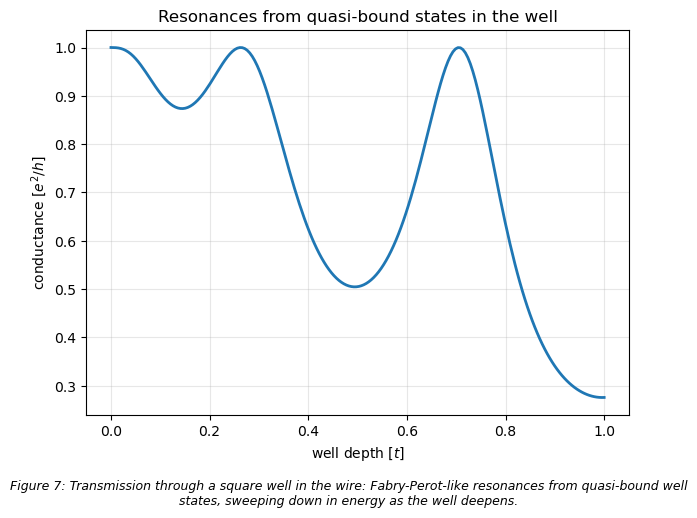

In [2]:
# --- A quantum well in a wire, swept over well depth -------------------------
import kwant, numpy as np
from matplotlib import pyplot

a, t, W, L = 1, 1.0, 10, 30
L_well = 10
lat = kwant.lattice.square(a, norbs=1)

def onsite(site, pot):
    (x, y) = site.pos
    # the well occupies the middle third of the wire
    inside = (L - L_well) // 2 <= x < (L + L_well) // 2
    return 4 * t + (pot if inside else 0)

syst = kwant.Builder()
syst[(lat(x, y) for x in range(L) for y in range(W))] = onsite
syst[lat.neighbors()] = -t

lead = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
lead[(lat(0, j) for j in range(W))] = 4 * t
lead[lat.neighbors()] = -t
syst.attach_lead(lead)
syst.attach_lead(lead.reversed())

fsyst_well = syst.finalized()

welldepths = np.linspace(0, 1.0, 200)
data = [kwant.smatrix(fsyst_well, 0.2, params=dict(pot=-wd)).transmission(1, 0)
        for wd in welldepths]

pyplot.plot(welldepths, data, lw=2)
pyplot.xlabel("well depth $[t]$")
pyplot.ylabel(r"conductance $[e^2/h]$")
pyplot.title("Resonances from quasi-bound states in the well")
pyplot.grid(alpha=.3); show_fig(r'Transmission through a square well in the wire: Fabry-Perot-like resonances from quasi-bound well states, sweeping down in energy as the well deepens.')

sites: 1857


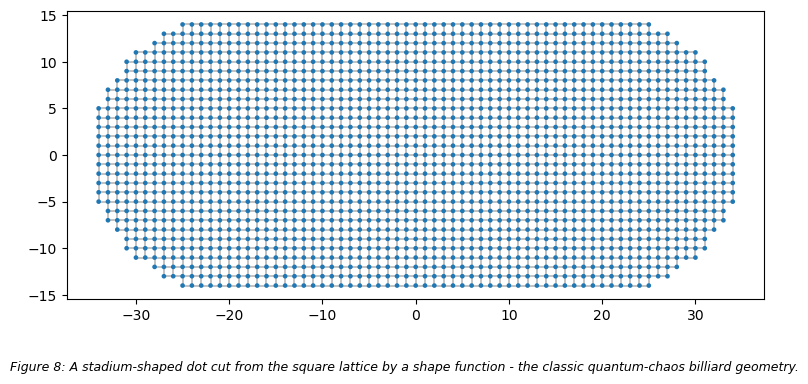

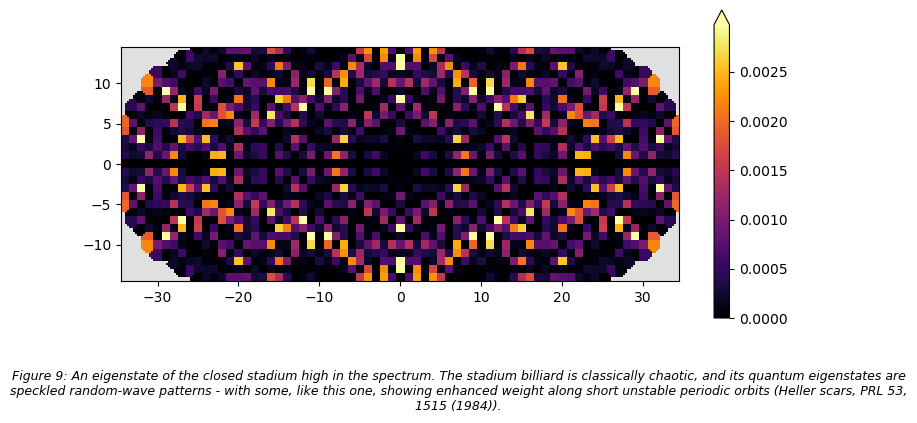

In [3]:
# --- Shape functions: a stadium-shaped quantum dot ---------------------------
import kwant
lat = kwant.lattice.square(norbs=1)

def stadium(pos):
    x, y = pos
    x = max(abs(x) - 20, 0)          # two half-discs joined by a straight section
    return x**2 + y**2 < 15**2

dot = kwant.Builder()
dot[lat.shape(stadium, (0, 0))] = 4.0
dot[lat.neighbors()] = -1.0

print("sites:", len(list(dot.sites())))
kwant.plot(dot, fig_size=(9, 4), site_size=0.25, hop_lw=0.05, show=False)
show_fig(r'A stadium-shaped dot cut from the square lattice by a shape function - the classic quantum-chaos billiard geometry.')

# an eigenstate of the closed stadium, high in the spectrum: quantum chaos
import numpy as np
import scipy.sparse.linalg as sla

fdot = dot.finalized()
ham = fdot.hamiltonian_submatrix(sparse=True)
ev_s, vec_s = sla.eigsh(ham.tocsc(), k=1, sigma=2.4)
kwant.plotter.map(fdot, np.abs(vec_s[:, 0]) ** 2, oversampling=4,
                  cmap='inferno', fig_size=(9, 4), show=False)
show_fig(r'An eigenstate of the closed stadium high in the spectrum. The stadium billiard is classically chaotic, and its quantum eigenstates are speckled random-wave patterns - with some, like this one, showing enhanced weight along short unstable periodic orbits (Heller scars, PRL 53, 1515 (1984)).')

---
## 6. Spin — matrix-valued on-site and hopping terms

To give each site internal structure (spin, orbitals, electron/hole), assign **matrices**
instead of numbers and declare `norbs` accordingly.

### The physics: Rashba spin–orbit coupling + Zeeman

$$H = \frac{p^2}{2m} + \frac{\alpha}{\hbar}\left(\sigma_x p_y - \sigma_y p_x\right)
+ \frac{E_Z}{2}\,\sigma_z$$

Discretising: the Rashba term is *first order* in momentum, so it becomes an **imaginary,
spin-flipping hopping**; the Zeeman term is diagonal and on-site.

$$H_{\text{onsite}} = (4t + E_Z\sigma_z),\qquad
H_{x\text{-hop}} = -t\sigma_0 + \frac{i\alpha}{2}\sigma_y,\qquad
H_{y\text{-hop}} = -t\sigma_0 - \frac{i\alpha}{2}\sigma_x .$$

Note the pattern: $\partial_x \to$ hopping along $x$ times $i$, and the Pauli matrix
attached is the *other* one, with a sign set by the cross product in the Rashba term.

Together, Rashba + Zeeman opens a **helical gap** at $k=0$: the two spin-split parabolas
anticross, leaving a window where only one pair of counter-propagating, spin-locked modes
exists. This is the ingredient that, combined with superconductivity, produces Majorana
bound states (§ 9).

> Use `tinyarray` for these small fixed matrices — it is dramatically faster than NumPy for
> 2×2 and 4×4 objects, which Kwant manipulates millions of times.

**Where Rashba coupling comes from.**  In a 2D electron gas the confining
potential breaks inversion along $\hat z$; relativistic corrections then read
$H_R = \alpha(\sigma_x k_y - \sigma_y k_x)$, with $\alpha$ tunable by a gate
— the basis of the Datta-Das spin-transistor proposal [APL **56**, 665
(1990)].  Combined with a Zeeman field it opens the *helical gap* probed
above: inside it, spin and direction of motion are locked, a 1D cousin of
the topological-insulator edge and the starting point of the Majorana wire
of §19.  *Further reading:* Winkler, *Spin-Orbit Coupling Effects in 2D
Electron and Hole Systems* (Springer, 2003); Manchon *et al.*, Nat. Mater.
**14**, 871 (2015).


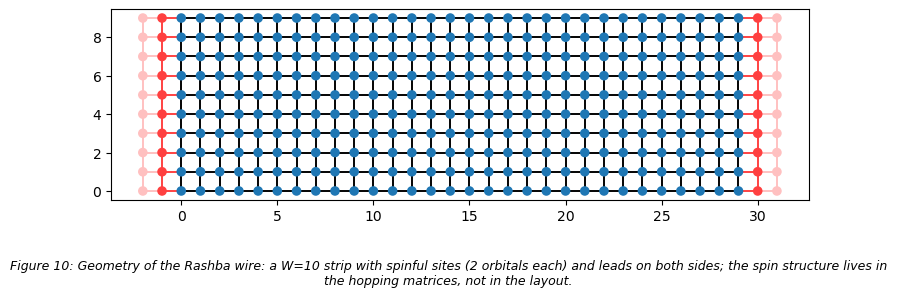

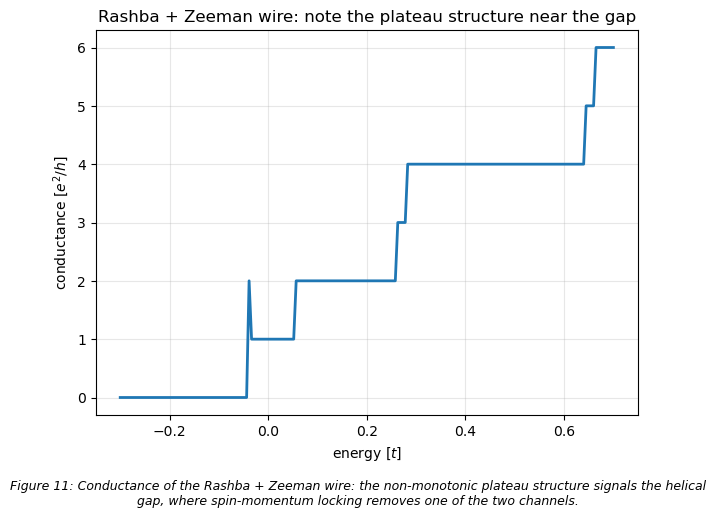

In [4]:
# --- Rashba wire: helical gap -------------------------------------------------
import kwant, numpy as np, tinyarray as ta
from matplotlib import pyplot

sigma_0 = ta.array([[1, 0], [0, 1]])
sigma_x = ta.array([[0, 1], [1, 0]])
sigma_y = ta.array([[0, -1j], [1j, 0]])
sigma_z = ta.array([[1, 0], [0, -1]])

t, alpha, e_z = 1.0, 0.5, 0.08
W, L = 10, 30
lat = kwant.lattice.square(norbs=2)          # 2 orbitals = spin up/down

def make_rashba(W=10, L=30):
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(L) for y in range(W))] = \
        4 * t * sigma_0 + e_z * sigma_z
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = \
        -t * sigma_0 + 1j * alpha * sigma_y / 2
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = \
        -t * sigma_0 - 1j * alpha * sigma_x / 2

    lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    lead[(lat(0, j) for j in range(W))] = 4 * t * sigma_0 + e_z * sigma_z
    lead[kwant.builder.HoppingKind((1, 0), lat, lat)] = \
        -t * sigma_0 + 1j * alpha * sigma_y / 2
    lead[kwant.builder.HoppingKind((0, 1), lat, lat)] = \
        -t * sigma_0 - 1j * alpha * sigma_x / 2

    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst

kwant.plot(make_rashba(), fig_size=(9, 3), show=False)
show_fig(r'Geometry of the Rashba wire: a W=10 strip with spinful sites (2 orbitals each) and leads on both sides; the spin structure lives in the hopping matrices, not in the layout.')

fsyst_r = make_rashba().finalized()

energies = np.linspace(-0.3, 0.7, 200)
data = [kwant.smatrix(fsyst_r, e).transmission(1, 0) for e in energies]

pyplot.plot(energies, data, lw=2)
pyplot.xlabel("energy $[t]$"); pyplot.ylabel(r"conductance $[e^2/h]$")
pyplot.title("Rashba + Zeeman wire: note the plateau structure near the gap")
pyplot.grid(alpha=.3); show_fig(r'Conductance of the Rashba + Zeeman wire: the non-monotonic plateau structure signals the helical gap, where spin-momentum locking removes one of the two channels.')

---
## 7. Band structure and closed systems

Not every calculation is a transport calculation. Kwant gives you the Hamiltonian itself.

### Lead band structure

A lead is periodic, so Bloch's theorem applies: $H(k) = H_{\text{cell}} + H_{\text{hop}}e^{ik} + H_{\text{hop}}^\dagger e^{-ik}$,
and diagonalising $H(k)$ gives the subbands. This is exactly what tells you **how many
modes are open** at a given energy — the step positions in § 3.

```python
bands = kwant.physics.Bands(flead)     # flead = lead.finalized()
energies = [bands(k) for k in momenta]
kwant.plotter.bands(flead)             # convenience wrapper
```

### Closed systems

Drop the leads and you have a finite Hermitian matrix. `hamiltonian_submatrix` hands it to
you and you use SciPy:

```python
ham = fsyst.hamiltonian_submatrix(params=..., sparse=True)
evals = scipy.sparse.linalg.eigsh(ham.tocsc(), k=15, sigma=0, return_eigenvectors=False)
```

> Use `sigma=0` with `eigsh` for **shift-invert** around zero energy. Asking for `which='SM'`
> without shift-invert converges painfully slowly. This is the single most common
> performance mistake in closed-system Kwant code.

### The Fock–Darwin spectrum

A 2D parabolic dot in a perpendicular field $B$ has levels
$$E_{n,\ell} = (2n + |\ell| + 1)\hbar\Omega - \tfrac{1}{2}\ell\hbar\omega_c,
\qquad \Omega = \sqrt{\omega_0^2 + \omega_c^2/4}.$$
At small $B$ the degeneracies split linearly (orbital Zeeman); at large $B$ the levels
bunch into **Landau levels**. A hard-wall disc shows the same qualitative flow, which is
what the next cell computes.

**Reading a lead's band structure.**  `kwant.physics.Bands` diagonalises the
lead's translation cell at fixed Bloch momentum — the 1D band structure
$E_n(k)$ whose minima open conductance channels and whose slopes are the
mode velocities that normalise the scattering matrix.  Everything transport
in this notebook is controlled by these curves; when in doubt about a
feature in $G(E)$, plot the bands first.  *Further reading:* Ashcroft &
Mermin ch. 8 for Bloch theory; Datta ch. 3 for modes-as-channels.


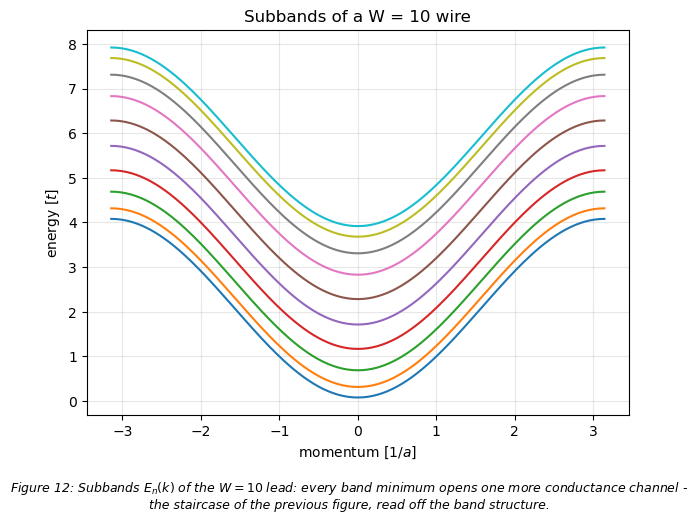

energies at k = 0: [0.081  0.3175 0.6903 1.1692 1.7154 2.2846 2.8308 3.3097 3.6825 3.919 ]


In [5]:
# --- Band structure of a lead ------------------------------------------------
import kwant, numpy as np
from matplotlib import pyplot

lat = kwant.lattice.square(norbs=1)
t, W = 1.0, 10

lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
lead[(lat(0, j) for j in range(W))] = 4 * t
lead[lat.neighbors()] = -t
flead = lead.finalized()

# convenience plot
kwant.plotter.bands(flead, momenta=np.linspace(-np.pi, np.pi, 201), show=False)
pyplot.xlabel("momentum $[1/a]$"); pyplot.ylabel("energy $[t]$")
pyplot.title("Subbands of a W = 10 wire"); pyplot.grid(alpha=.3); show_fig(r'Subbands $E_n(k)$ of the $W=10$ lead: every band minimum opens one more conductance channel - the staircase of the previous figure, read off the band structure.')

# ... and the underlying object, if you want the numbers
bands = kwant.physics.Bands(flead)
print("energies at k = 0:", np.round(bands(0.0), 4))

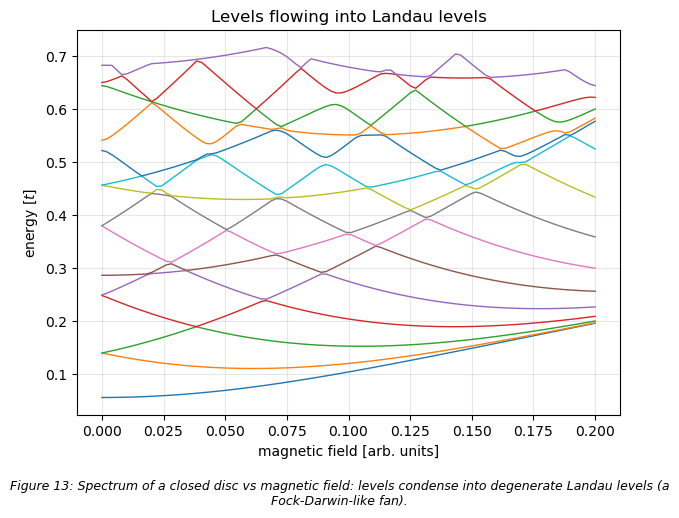

In [6]:
# --- Closed system: spectrum of a disc vs magnetic field (Fock-Darwin-like) ---
import kwant, numpy as np
import scipy.sparse.linalg as sla
from cmath import exp
from matplotlib import pyplot

lat = kwant.lattice.square(norbs=1)
t, r = 1.0, 10

def circle(pos):
    x, y = pos
    return x**2 + y**2 < r**2

def hopx(site1, site2, B):
    # Peierls phase for a uniform field in the Landau gauge A = (-By, 0, 0)
    y = site1.pos[1]
    return -t * exp(-1j * B * y)

dot = kwant.Builder()
dot[lat.shape(circle, (0, 0))] = 4 * t
dot[kwant.builder.HoppingKind((1, 0), lat, lat)] = hopx
dot[kwant.builder.HoppingKind((0, 1), lat, lat)] = -t
fdot = dot.finalized()

Bfields = np.linspace(0, 0.2, 100)
energies = []
for B in Bfields:
    ham = fdot.hamiltonian_submatrix(params=dict(B=B), sparse=True)
    ev = sla.eigsh(ham.tocsc(), k=15, sigma=0, return_eigenvectors=False)
    energies.append(np.sort(ev))

pyplot.plot(Bfields, energies, lw=1)
pyplot.xlabel("magnetic field [arb. units]"); pyplot.ylabel("energy $[t]$")
pyplot.title("Levels flowing into Landau levels"); pyplot.grid(alpha=.3); show_fig(r'Spectrum of a closed disc vs magnetic field: levels condense into degenerate Landau levels (a Fock-Darwin-like fan).')